Вторая подзадача задачи 3:
Пусть есть $I_{1}, ... , I_{N}$ изображения. Также даны $M_{1}, ... , M_{N}$ - матрицы маски, полученные после сегментации облаков в первой подзадаче

In [109]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt


In [110]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [111]:
def load_images_from_folder(folder):
    images = []
    for filename in sorted(os.listdir(folder)):
        if filename.lower().endswith(('.png', '.jpg', '.jpeg')):
            img = cv2.imread(os.path.join(folder, filename))
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            images.append(img)
    return np.array(images)

In [112]:
def local_variance(gray, ksize=7):
    gray = gray.astype(np.float32)
    mean = cv2.blur(gray, (ksize, ksize))
    mean_sq = cv2.blur(gray*gray, (ksize, ksize))
    return mean_sq - mean*mean


In [113]:
def cloud_mask_ternary(img):
    #Бинарная маска
    hsv = cv2.cvtColor(img, cv2.COLOR_RGB2HSV)
    H, S, V = hsv[...,0], hsv[...,1], hsv[...,2]

    _, mask_v = cv2.threshold(V, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    _, mask_s = cv2.threshold(S, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

    mask_bin = cv2.bitwise_and(mask_v, mask_s)
    mask_bin = (mask_bin > 0).astype(np.uint8)

    #Локальная дисперсия
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    var = local_variance(gray, ksize=7)

    # Порог по дисперсии внутри облака
    cloud_pixels = var[mask_bin == 1]
    if len(cloud_pixels) == 0:
        return mask_bin  # нет облаков ==  0

    T = np.percentile(cloud_pixels, 40)

    #Тернарная маска
    tern = np.zeros_like(mask_bin)

    # плотное облако
    tern[(mask_bin == 1) & (var < T)] = 1

    # полупрозрачное облако
    tern[(mask_bin == 1) & (var >= T)] = 2

    return tern

In [114]:
mask_massive = np.load("drive/MyDrive/hackathon_3_problemm/1.npy")

In [115]:
print(mask_massive.shape)
print(np.unique(mask_massive))

(405, 736)
[0 1 2]


In [116]:
def build_masks_for_dir2(img_massive):
    masks = []
    for img in img_massive:
        masks.append(cloud_mask_ternary(img))
    return np.array(masks)

In [117]:
def subtask2(img_massive, mask_massive, alpha=0.2):
    N, H, W, C = img_massive.shape

    clean_mask = (mask_massive == 0)
    semi_mask  = (mask_massive == 2)

    clean_mask_4d = clean_mask[..., None]
    semi_mask_4d  = semi_mask[..., None]

    clean_weights = clean_mask_4d.astype(np.float32)
    semi_weights  = semi_mask_4d.astype(np.float32) * alpha

    total_weights = clean_weights + semi_weights

    weighted_sum = img_massive * clean_weights + img_massive * semi_weights

    sum_pixels = weighted_sum.sum(axis=0)
    sum_weights = total_weights.sum(axis=0)

    result_img = np.zeros((H, W, 3), dtype=np.float32)
    white = np.array([255, 255, 255], dtype=np.float32)

    valid = (sum_weights[..., 0] > 0)

    result_img[valid] = (sum_pixels[valid] / sum_weights[valid])
    result_img[~valid] = white

    return result_img.astype(np.uint8)


In [118]:
def visualize_subtask2(img_massive, mask_massive, result_img):
    N = img_massive.shape[0]

    fig, axes = plt.subplots(2, N, figsize=(4*N, 8))

    for i in range(N):
        axes[0, i].imshow(img_massive[i])
        axes[0, i].set_title(f"Кадр {i}")
        axes[0, i].axis("off")

        axes[1, i].imshow(mask_massive[i], cmap='viridis')
        axes[1, i].set_title(f"Маска {i} (0/1/2)")
        axes[1, i].axis("off")

    plt.suptitle("Входные изображения и маски", fontsize=16)
    plt.show()

    plt.figure(figsize=(8, 8))
    plt.imshow(result_img)
    plt.title("Итоговая карта местности")
    plt.axis("off")
    plt.savefig('result_task2.png')
    plt.show()


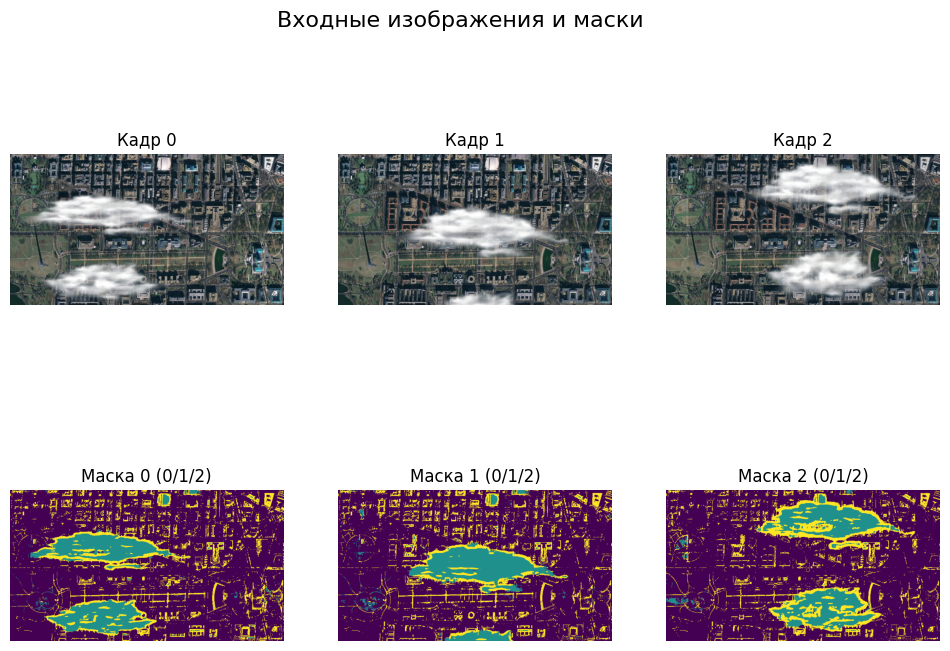

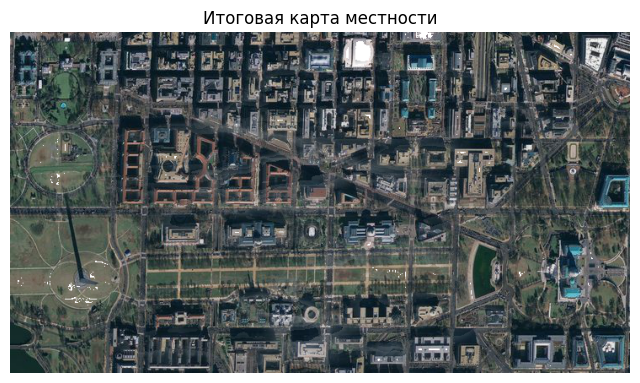

In [119]:
dir2_path = "drive/MyDrive/hackathon_3_problemm/dir2"

# 1. Загружаем изображения
img_massive = load_images_from_folder(dir2_path)

# 2. Строим тернарные маски
mask_massive = build_masks_for_dir2(img_massive)

# 3. Собираем карту
result_img = subtask2(img_massive, mask_massive, alpha=0.2)

# 4. Визуализируем
visualize_subtask2(img_massive, mask_massive, result_img)
